### An example, bootstrapping modeled NAO indices to produce single member samples

In [41]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from math import nan
import matplotlib.pyplot as plt

from rossby_utils import bootstrap_utils as boot
from rossby_utils import plothisto_utils as histo

### Reading in the data

In [9]:
era5 = xr.open_dataset(
    "/glade/campaign/cgd/cas/islas/python_savs/rossbypalooza26/processing/ERA5/ERA5_monthly_slp_1993_2025.nc").slp
cesm2 = xr.open_dataset(
    "/glade/campaign/cgd/cas/islas/python_savs/rossbypalooza26/processing/CESM2/SMYLE_ERA_L32/CESM2_SMYLE_ERA5_L32slp_1993_2020.nc").slp

### Selecting only years 1993 - 2016

In [10]:
era5 = era5.sel(year=slice(1993,2016))
cesm2 = cesm2.sel(year=slice(1993,2016))

### Calculating the station based NAO

In [23]:
### Remove the lead dependent climatology
era5_anoms = era5 - era5.mean('year')
cesm2_anoms = cesm2 - cesm2.mean('year')

### Normalize each month by its standard deviation
era5_norm = era5_anoms / era5_anoms.std('year')
cesm2_norm = cesm2_anoms / cesm2_anoms.std('year')

### 
# Iceland lon and lat 
lon_ice = 360 - 21.9 ; lat_ice = 64.1
# Azores lon and lat
lon_az = 360 - 28 ; lat_az = 39.5

era5_nao = era5_norm.sel(lon=lon_az, lat=lat_az, method='nearest') - era5_norm.sel(lon=lon_ice, lat=lat_ice, method='nearest')
cesm2_nao = cesm2_norm.sel(lon=lon_az, lat=lat_az, method='nearest') - cesm2_norm.sel(lon=lon_ice, lat=lat_ice, method='nearest')

era5_nao_djf = era5_nao.isel(lead=slice(1,4)).mean('lead')
cesm2_nao_djf = cesm2_nao.isel(lead=slice(1,4)).mean('lead')

era5_nao_djf = era5_nao_djf.compute()
cesm2_nao_djf = cesm2_nao_djf.compute()

### Bootstrapped single member samples of the modeled NAO

In [29]:
boot_nao = []
for iyear in np.arange(0,cesm2_nao_djf.year.size,1): # Loop over years

    # Use the bootstrapping function in ./rossby_utils/bootstra_utils.py to randomly sample 1000 members for this year
    # This is using iyear for the random number seed so that the random number seed will be different for each year
    # The resulting array is is a one dimensional array of length 1000 (or nboots)
    boot_temp = boot.bootgen(cesm2_nao_djf.isel(year=iyear), nsamples=1, seed=iyear, nboots=1000).isel(isample=0)

    # append the bootstrapped array to boot_nao which will eventually contain the bootstrapped arrays for all members
    boot_nao.append(boot_temp)

# Concatenate the list of arrays to give an array of the form (year, nboots)
boot_nao = xr.concat(boot_nao, dim=cesm2_nao_djf.year)

In [39]:
### Example, exploring the correlations with the ensemble mean
era5_cor = xr.corr(era5_nao_djf, cesm2_nao_djf.mean('member'), dim='year')
cesm2_boot_cor = xr.corr(boot_nao, cesm2_nao_djf.mean('member'), dim='year')

### Plot a histogram of the CESM2 bootstrapped single member samples correlated with the CESM2 ensemble mean, versus the ERA5 correlation with the CESM2 ensemble mean

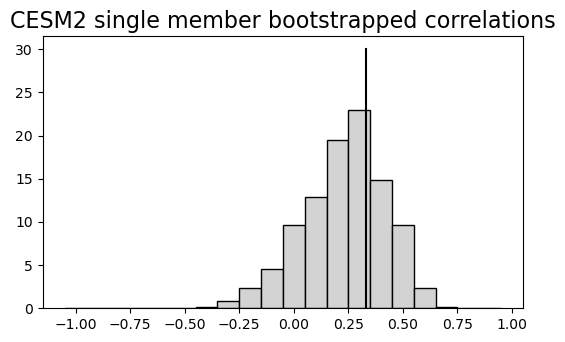

In [47]:
fig = plt.figure(figsize=(16,16))

ax = histo.plothisto(fig, cesm2_boot_cor,np.arange(-1,1.1,0.1),0.02,0.32,0.8,0.97, percent=True, title='CESM2 single member bootstrapped correlations')
ax.plot([era5_cor, era5_cor],[0,30], color='black')